In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import csv
import nltk
import re
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

## LOADING DATASET

In [ ]:
df = pd.read_csv("yelp_training_set_flattened.csv", encoding = 'utf-8', engine='python')

print(f"Loaded Successfully!")
print(f"Shape: {df.shape}")
df.head()

Loaded Successfully!
Shape: (23030, 32)


,Unnamed: 0,business_blank,business_categories,business_city,business_full_address,business_id,business_latitude,business_longitude,business_name,business_neighborhoods,...,reviewer_funny,reviewer_name,reviewer_review_count,reviewer_type,reviewer_useful,stars,text,type,useful,user_id
0,0,False,Breakfast & Brunch; Restaurants,Phoenix,"6106 S 32nd St\nPhoenix, AZ 85042",9yKzy9PApeiPPOUJEtnvkg,33.390792,-112.012504,Morning Glory Cafe,NaN,...,331.0,Jason,376.0,user,1034.0,5.0,My wife took me here on my birthday for breakf...,review,5.0,rLtl8ZkDX5vH5nAx9C3q5Q
1,1,False,Italian; Pizza; Restaurants,Phoenix,"4848 E Chandler Blvd\nPhoenix, AZ 85044",ZRJwVLyzEJq1VAihDhYiow,33.305607,-111.978758,Spinato's Pizzeria,NaN,...,2.0,Paul,2.0,user,0.0,5.0,I have no idea why some people give bad review...,review,0.0,0a2KyEL0d3Yb1V6aivbIuQ
2,2,False,Middle Eastern; Restaurants,Tempe,"1513 E Apache Blvd\nTempe, AZ 85281",6oRAC4uyJCsJl1X0WZpVSA,33.414345,-111.913031,Haji-Baba,NaN,...,0.0,Nicole,3.0,user,3.0,4.0,love the gyro plate. Rice is so good and I als...,review,1.0,0hT2KtfLiobPvh6cDC8JQg
3,3,False,Active Life; Dog Parks; Parks,Scottsdale,"5401 N Hayden Rd\nScottsdale, AZ 85250",_1QQZuf4zZOyFCvXc0o6Vg,33.522945,-111.907886,Chaparral Dog Park,NaN,...,18.0,lindsey,31.0,user,75.0,5.0,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,2.0,uZetl9T0NcROGOyFfughhg
4,4,False,Tires; Automotive,Mesa,"1357 S Power Road\nMesa, AZ 85206",6ozycU1RpktNG2-1BroVtw,33.391027,-111.684482,Discount Tire,NaN,...,3.0,Roger,28.0,user,32.0,5.0,General Manager Scott Petello is a good egg!!!...,review,0.0,vYmM4KTsC8ZfQBg-j5MWkw


## TAKING ONLY 5000 ROWS AS PER PAPER

In [ ]:

df = df[df['business_categories'].str.contains(
    'Restaurant|Food', case=False, na=False
)]
df = df[df["stars"] != 3].reset_index(drop=True)
df = df.head(5000)
print(f"Paper Dataset (5000 reviews, no neutral stars): {df.shape}")
print(" Dataset Loaded!")

Paper Dataset (5000 reviews, no neutral stars): (5000, 32)
 Dataset Loaded!


In [ ]:

print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("PAPER METRICS (Table 3):")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"Total Reviews     : 5000")
print(f"Unique Businesses : 2783")
print(f"Unique Users      : 3676")
print(f"Total Funny Votes : 3436")
print(f"Total Cool Votes  : 4350")

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("YOUR METRICS:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"Total Reviews     : {len(df)}")
print(f"Unique Businesses : {df['business_id'].nunique()}")
print(f"Unique Users      : {df['user_id'].nunique()}")
print(f"Total Funny Votes : {int(pd.to_numeric(df['funny'], errors='coerce').fillna(0).sum())}")
print(f"Total Cool Votes  : {int(pd.to_numeric(df['cool'], errors='coerce').fillna(0).sum())}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PAPER METRICS (Table 3):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Reviews     : 5000
Unique Businesses : 2783
Unique Users      : 3676
Total Funny Votes : 3436
Total Cool Votes  : 4350

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YOUR METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Reviews     : 5000
Unique Businesses : 2167
Unique Users      : 3816
Total Funny Votes : 3467
Total Cool Votes  : 4444
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
df.head()

,Unnamed: 0,business_blank,business_categories,business_city,business_full_address,business_id,business_latitude,business_longitude,business_name,business_neighborhoods,...,reviewer_funny,reviewer_name,reviewer_review_count,reviewer_type,reviewer_useful,stars,text,type,useful,user_id
0,0,False,Breakfast & Brunch; Restaurants,Phoenix,"6106 S 32nd St\nPhoenix, AZ 85042",9yKzy9PApeiPPOUJEtnvkg,33.390792,-112.012504,Morning Glory Cafe,NaN,...,331.0,Jason,376.0,user,1034.0,5.0,My wife took me here on my birthday for breakf...,review,5.0,rLtl8ZkDX5vH5nAx9C3q5Q
1,1,False,Italian; Pizza; Restaurants,Phoenix,"4848 E Chandler Blvd\nPhoenix, AZ 85044",ZRJwVLyzEJq1VAihDhYiow,33.305607,-111.978758,Spinato's Pizzeria,NaN,...,2.0,Paul,2.0,user,0.0,5.0,I have no idea why some people give bad review...,review,0.0,0a2KyEL0d3Yb1V6aivbIuQ
2,2,False,Middle Eastern; Restaurants,Tempe,"1513 E Apache Blvd\nTempe, AZ 85281",6oRAC4uyJCsJl1X0WZpVSA,33.414345,-111.913031,Haji-Baba,NaN,...,0.0,Nicole,3.0,user,3.0,4.0,love the gyro plate. Rice is so good and I als...,review,1.0,0hT2KtfLiobPvh6cDC8JQg
3,5,False,Wine Bars; Bars; American (New); Nightlife; Re...,Phoenix,"6106 S 32nd St\nPhoenix, AZ 85042",-yxfBYGB6SEqszmxJxd97A,33.390792,-112.012504,Quiessence Restaurant,NaN,...,743.0,Deborah,654.0,user,1584.0,4.0,"Quiessence is, simply put, beautiful. Full wi...",review,3.0,sqYN3lNgvPbPCTRsMFu27g
4,6,False,Mexican; Restaurants,Phoenix,"1919 N 16th St\nPhoenix, AZ 85006",zp713qNhx8d9KCJJnrw1xA,33.469132,-112.047512,La Condesa Gourmet Taco Shop,NaN,...,1187.0,Monique,295.0,user,1376.0,5.0,Drop what you're doing and drive here. After I...,review,7.0,wFweIWhv2fREZV_dYkz_1g


## FEATURES REQUIRED FROM PAPER TABLE 4

In [ ]:
required_columns = [
    'business_blank',
    'business_categories',
    'business_city',
    'business_full_address',
    'business_id',
    'business_latitude',
    'business_longitude',
    'business_name',
    'business_open',
    'business_review_count',
    'business_stars',
    'business_state',
    'business_type',
    'cool',
    'date',
    'funny',
    'review_id',
    'reviewer_average_stars',
    'reviewer_blank',
    'reviewer_cool',
    'reviewer_funny',
    'reviewer_name',
    'reviewer_review_count',
    'reviewer_type',
    'reviewer_useful',
    'stars',
    'text',
    'type',
    'useful',
    'user_id'
]

## KEEPING ONLY EXISTING COLUMNS

In [ ]:
existing_cols = [col for col in required_columns
                 if col in df.columns
                 ]
df = df[existing_cols]
print(f"\nFeatures selected: {len(existing_cols)}")
df.shape


Features selected: 30


(5000, 30)

## HANDLE MISSING VALUES

In [ ]:
df = df.reset_index(drop=True)

df['text'] = df['text'].fillna('no review')

df['business_categories'] = df[
    'business_categories'].fillna('Unknown')

df['business_city'] = df[
    'business_city'].fillna('Unknown')

df['business_full_address'] = df[
    'business_full_address'].fillna('Unknown')

df['business_review_count'] = df[
    'business_review_count'].fillna(0)

df['business_stars'] = df[
    'business_stars'].fillna(
    df['business_stars'].mean())

df['reviewer_name'] = df[
    'reviewer_name'].fillna('Anonymous')

print("Missing values check:")
print(df.isnull().sum())
print("\n All columns complete!")
print(f"Shape: {df.shape}")

Missing values check:
business_blank            0
business_categories       0
business_city             0
business_full_address     0
business_id               0
business_latitude         0
business_longitude        0
business_name             0
business_open             0
business_review_count     0
business_stars            0
business_state            0
business_type             0
cool                      0
date                      0
funny                     0
review_id                 0
reviewer_average_stars    0
reviewer_blank            0
reviewer_cool             0
reviewer_funny            0
reviewer_name             0
reviewer_review_count     0
reviewer_type             0
reviewer_useful           0
stars                     0
text                      0
type                      0
useful                    0
user_id                   0
dtype: int64

 All columns complete!
Shape: (5000, 30)


In [ ]:
print("STAR DISTRIBUTION:")
print("------------------------------")
print(df['stars'].value_counts().sort_index())
print("Total reviews :: ", len(df['stars']))

df['sentiment_label'] = df['stars'].apply(
    lambda x : 1 if x >= 4
    else 0
)

print("\nSENTIMENT DISTRIBUTION:")
print("------------------------------")
print(df['sentiment_label'].value_counts().sort_index())
print("Total reviews :: ", len(df['sentiment_label']))

STAR DISTRIBUTION:
------------------------------
stars
1.0     393
2.0     580
4.0    2191
5.0    1836
Name: count, dtype: int64
Total reviews ::  5000

SENTIMENT DISTRIBUTION:
------------------------------
sentiment_label
0     973
1    4027
Name: count, dtype: int64
Total reviews ::  5000


## IMBALANCE IN REVIEWS (THERE ARE 973 -VE AND ALL REMAINING ARE +VE ) SO USING CLASS WEIGHTS TO BALANCE FOR BERT MODEL

In [ ]:
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.array([0, 1]),
    y = df['sentiment_label']
)

class_weight_dict = {
    0 : class_weights[0],
    1 : class_weights[1]
}

print(f"Negative (0): {class_weights[0]:.4f}")
print(f"Positive (1): {class_weights[1]:.4f}")
print("\nMeaning:")
print(f"→ BERT gives {class_weights[0]:.1f}x")
print(f"  more importance to Negative")
print(f"→ BERT gives {class_weights[1]:.1f}x")
print(f"  importance to Positive")
print(" Class Weights Ready for BERT!")

Negative (0): 2.5694
Positive (1): 0.6208

Meaning:
→ BERT gives 2.6x
  more importance to Negative
→ BERT gives 0.6x
  importance to Positive
 Class Weights Ready for BERT!


In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

## FUNCTION FOR PREPROCESSING

In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

"""| POS Tag | Starts With | WordNet Format | Example |
|---|---|---|---|
| Adjective | `J` | `wordnet.ADJ` | `JJ` → good, beautiful |
| Verb | `V` | `wordnet.VERB` | `VB` → run, eat |
| Noun | `N` | `wordnet.NOUN` | `NN` → food, restaurant |
| Adverb | `R` | `wordnet.ADV` | `RB` → quickly, very |
| Others | anything else | `wordnet.NOUN` | default |"""

def preprocess_text(text):

    # Clean text
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 1: Tokenization
    tokens = word_tokenize(text)

    # Step 2: Stop Words Removal
    tokens = [
        t for t in tokens
        if t not in stop_words
        and len(t) > 2
    ]

    # Step 3: POS Tagging
    pos_tags = pos_tag(tokens)

    # Step 4: WordNet POS Information
    # Step 5: Lemmatization
    tokens = [
        lemmatizer.lemmatize(
            token,
            get_wordnet_pos(tag)
        )
        for token, tag in pos_tags
    ]

    return ' '.join(tokens)


## EXAMPLE COMPARING (BEFORE PREPROCESSING AND AFTER PREPROCESSING)

In [ ]:
print(df['text'].iloc[0])

My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!


In [ ]:

sample = df['text'].iloc[0]
clean  = preprocess_text(sample)

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("BEFORE vs AFTER (Figure 2):")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"BEFORE:\n{sample}")
print(f"\nAFTER:\n{clean}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEFORE vs AFTER (Figure 2):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BEFORE:
My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.

Do yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I've ever had.  I'm pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.

While EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I've ever had.

Anyway, I can't wait to go back!

AFTER:

## APPLY TO ALL REVIEWS

In [ ]:
print("\n Preprocessing all reviews...")
print("Please wait 2-3 minutes...")

df['clean_text'] = df['text'].apply(
    preprocess_text
)

print(" All Reviews Preprocessed!")


 Preprocessing all reviews...
Please wait 2-3 minutes...
 All Reviews Preprocessed!


## GRAPH FOR STAR DISTRIBUTION

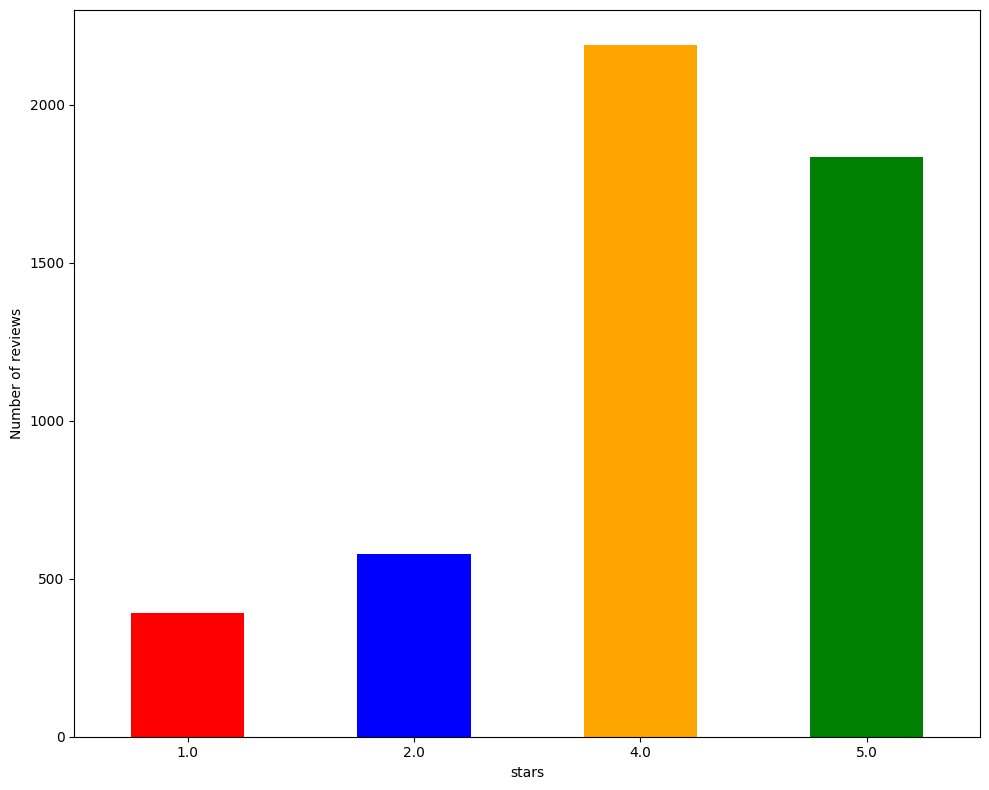

In [ ]:
plt.figure(figsize = (10, 8))
colors = ['red', 'blue', 'orange', 'green']
df['stars'].value_counts().sort_index().plot(kind='bar',color=colors)
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('star_distribution.png')
plt.show()

## GRAPH FOR SENTIMENT LABELS

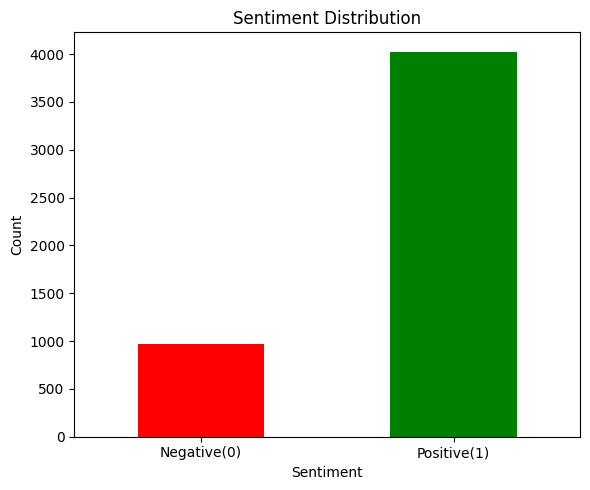

In [ ]:
plt.figure(figsize=(6,5))
colors = ['red','green']
df['sentiment_label'].value_counts().sort_index().plot(kind='bar',color=colors)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(
    [0,1],
    ['Negative(0)','Positive(1)'],
    rotation=0
)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

## FINAL SUMMARY

In [ ]:
print(f"Total Reviews     : {len(df)}")
print(f"Unique Users      : {df['user_id'].nunique()}")
print(f"Unique Businesses : {df['business_id'].nunique()}")
print(f"Negative Reviews  : {sum(df['sentiment_label']==0)}")
print(f"Positive Reviews  : {sum(df['sentiment_label']==1)}")
print(f"\nClass Weights for BERT:")
print(f"Negative (0) : {class_weights[0]:.4f}")
print(f"Positive (1) : {class_weights[1]:.4f}")

Total Reviews     : 5000
Unique Users      : 3816
Unique Businesses : 2167
Negative Reviews  : 973
Positive Reviews  : 4027

Class Weights for BERT:
Negative (0) : 2.5694
Positive (1) : 0.6208


In [ ]:
df.to_csv('preprocessed_yelp.csv',
          index=False)
np.save('class_weights.npy',
        class_weights)

In [ ]:
df.columns

Index(['business_blank', 'business_categories', 'business_city',
       'business_full_address', 'business_id', 'business_latitude',
       'business_longitude', 'business_name', 'business_open',
       'business_review_count', 'business_stars', 'business_state',
       'business_type', 'cool', 'date', 'funny', 'review_id',
       'reviewer_average_stars', 'reviewer_blank', 'reviewer_cool',
       'reviewer_funny', 'reviewer_name', 'reviewer_review_count',
       'reviewer_type', 'reviewer_useful', 'stars', 'text', 'type', 'useful',
       'user_id', 'sentiment_label', 'clean_text'],
      dtype='object')

In [ ]:
df.head()

,business_blank,business_categories,business_city,business_full_address,business_id,business_latitude,business_longitude,business_name,business_open,business_review_count,...,reviewer_review_count,reviewer_type,reviewer_useful,stars,text,type,useful,user_id,sentiment_label,clean_text
0,False,Breakfast & Brunch; Restaurants,Phoenix,"6106 S 32nd St\nPhoenix, AZ 85042",9yKzy9PApeiPPOUJEtnvkg,33.390792,-112.012504,Morning Glory Cafe,True,116.0,...,376.0,user,1034.0,5.0,My wife took me here on my birthday for breakf...,review,5.0,rLtl8ZkDX5vH5nAx9C3q5Q,1,wife take birthday breakfast excellent weather...
1,False,Italian; Pizza; Restaurants,Phoenix,"4848 E Chandler Blvd\nPhoenix, AZ 85044",ZRJwVLyzEJq1VAihDhYiow,33.305607,-111.978758,Spinato's Pizzeria,True,102.0,...,2.0,user,0.0,5.0,I have no idea why some people give bad review...,review,0.0,0a2KyEL0d3Yb1V6aivbIuQ,1,idea people give bad review place go show plea...
2,False,Middle Eastern; Restaurants,Tempe,"1513 E Apache Blvd\nTempe, AZ 85281",6oRAC4uyJCsJl1X0WZpVSA,33.414345,-111.913031,Haji-Baba,True,265.0,...,3.0,user,3.0,4.0,love the gyro plate. Rice is so good and I als...,review,1.0,0hT2KtfLiobPvh6cDC8JQg,1,love gyro plate rice good also dig candy selec...
3,False,Wine Bars; Bars; American (New); Nightlife; Re...,Phoenix,"6106 S 32nd St\nPhoenix, AZ 85042",-yxfBYGB6SEqszmxJxd97A,33.390792,-112.012504,Quiessence Restaurant,True,109.0,...,654.0,user,1584.0,4.0,"Quiessence is, simply put, beautiful. Full wi...",review,3.0,sqYN3lNgvPbPCTRsMFu27g,1,quiessence simply put beautiful full window ea...
4,False,Mexican; Restaurants,Phoenix,"1919 N 16th St\nPhoenix, AZ 85006",zp713qNhx8d9KCJJnrw1xA,33.469132,-112.047512,La Condesa Gourmet Taco Shop,True,307.0,...,295.0,user,1376.0,5.0,Drop what you're doing and drive here. After I...,review,7.0,wFweIWhv2fREZV_dYkz_1g,1,drop youre drive ate back next day food good c...


In [ ]:
import torch

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Using CPU.")

Tesla T4


## SENTIMENTAL ANALYSIS

In [ ]:
!pip install afinn
!pip install textblob
!pip install vaderSentiment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=5b9c118e93b8b9bee53b5cd4009ccb720d109828ec75b266750ae6f53893b432
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.9 MB/s eta 0:00:00


In [ ]:
from afinn import Afinn
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

## PREPARING DATA FOR SPLIT

In [ ]:
X = df['text']
Y = df['sentiment_label']
print("Total samples ::", len(df['text']))
print("Total positive samples ::", sum(df['sentiment_label']==1) )
print("Total negative samples ::", sum(df['sentiment_label']==0))


Total samples :: 5000
Total positive samples :: 4027
Total negative samples :: 973


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)


print(f"\nTrain Size : {len(x_train)}")
print(f"Test Size  : {len(x_test)}")


Train Size : 3500
Test Size  : 1500


## AFINN - SENTIMENTAL ANALYSIS

In [ ]:
afinn = Afinn()
def afinn_sentiment(texts):
  predictions = []
  for text in texts:
    value = afinn.score(str(text))
    if value > 0 :
      predictions.append(1)
    else :
      predictions.append(0)
  return predictions

afinn_predict = afinn_sentiment(x_test)
print("AFINN DONE!!")

AFINN DONE!!


## AFINN EVALUATION



In [ ]:
afinn_accuracy  = accuracy_score(y_test, afinn_predict)
afinn_precision = precision_score(y_test, afinn_predict)
afinn_recall    = recall_score(y_test, afinn_predict)
afinn_f1 = f1_score(y_test, afinn_predict)

print(f"Accuracy  : {afinn_accuracy  * 100:.2f}%")
print(f"Precision : {afinn_precision * 100:.2f}%")
print(f"Recall    : {afinn_recall    * 100:.2f}%")
print(f"F1 Score  : {afinn_f1        * 100:.2f}%")

Accuracy  : 83.73%
Precision : 84.68%
Recall    : 97.15%
F1 Score  : 90.49%


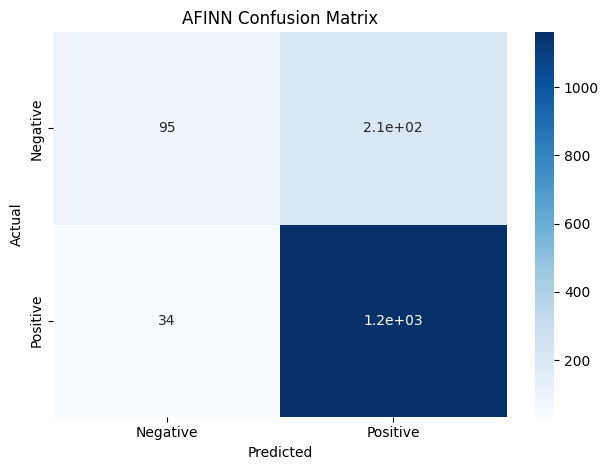


 AFINN predictions copied into dataframe 


In [ ]:
afinn_cm = confusion_matrix(y_test, afinn_predict)

sns.heatmap(afinn_cm, annot = True, cmap = 'Blues', xticklabels= ['Negative', 'Positive'], yticklabels= ['Negative', 'Positive'] )
plt.title('AFINN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('afinn_confusion_matrix.png')
plt.show()


df['afinn_sentiment'] = afinn_sentiment(df['text'])
print("\n AFINN predictions copied into dataframe ")

## TEXTBLOB - SENTIMENTAL ANALYSIS

In [ ]:
def textblob_sentiment(texts):
    predictions = []
    for text in texts:
        blob     = TextBlob(str(text))
        polarity = blob.sentiment.polarity
        if polarity > 0:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions


In [ ]:
textblob_predict = textblob_sentiment(x_test)
print(" TEXTBLOB DONE!!")

 TEXTBLOB DONE!!


## TEXTBLOB EVALUATION

In [ ]:
textblob_accuracy  = accuracy_score(y_test, textblob_predict)
textblob_precision = precision_score(y_test, textblob_predict)
textblob_recall    = recall_score(y_test, textblob_predict)
textblob_f1        = f1_score(y_test, textblob_predict)

print(f"Accuracy  : {textblob_accuracy  * 100:.2f}%")
print(f"Precision : {textblob_precision * 100:.2f}%")
print(f"Recall    : {textblob_recall    * 100:.2f}%")
print(f"F1 Score  : {textblob_f1        * 100:.2f}%")

Accuracy  : 83.33%
Precision : 84.41%
Recall    : 96.99%
F1 Score  : 90.26%


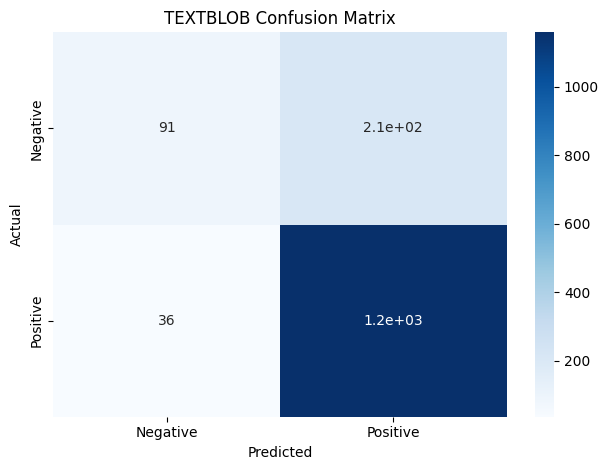


 TEXTBLOB predictions copied into dataframe 


In [ ]:
textblob_cm = confusion_matrix(y_test, textblob_predict)

sns.heatmap(textblob_cm, annot = True, cmap = 'Blues', xticklabels= ['Negative', 'Positive'], yticklabels= ['Negative', 'Positive'] )
plt.title('TEXTBLOB Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('textblob_confusion_matrix.png')
plt.show()


df['textblob_sentiment'] = textblob_sentiment(df['text'])
print("\n TEXTBLOB predictions copied into dataframe ")

## VADER - SENTIMENTAL ANALYSIS

In [ ]:
vader = SentimentIntensityAnalyzer()

def vader_sentiment(texts):
    predictions = []
    for text in texts:
        scores   = vader.polarity_scores(str(text))
        compound = scores['compound']
        if compound >= 0.05:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

vader_predict = vader_sentiment(x_test)
print("VADER DONE!!")

VADER DONE!!


## VADER EVALUATION

In [ ]:
vader_accuracy  = accuracy_score(y_test, vader_predict)
vader_precision = precision_score(y_test, vader_predict)
vader_recall    = recall_score(y_test, vader_predict)
vader_f1        = f1_score(y_test, vader_predict)

print(f"Accuracy  : {vader_accuracy  * 100:.2f}%")
print(f"Precision : {vader_precision * 100:.2f}%")
print(f"Recall    : {vader_recall    * 100:.2f}%")
print(f"F1 Score  : {vader_f1        * 100:.2f}%")

Accuracy  : 85.73%
Precision : 86.04%
Recall    : 97.99%
F1 Score  : 91.63%


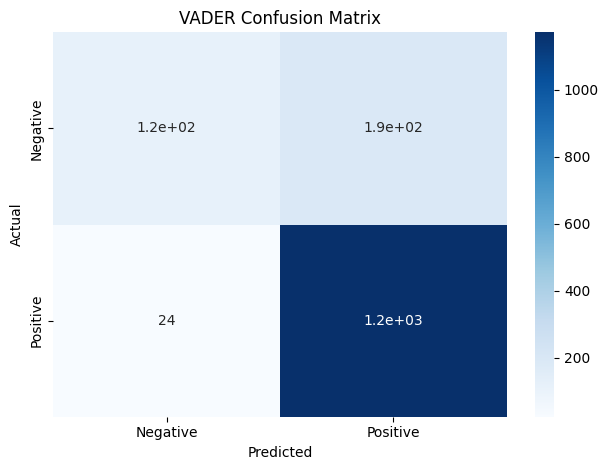


 VADER predictions copied into dataframe


In [ ]:

vader_cm = confusion_matrix(y_test, vader_predict)

sns.heatmap(vader_cm, annot = True, cmap = 'Blues', xticklabels = ['Negative', 'Positive'], yticklabels = ['Negative', 'Positive']
)
plt.title('VADER Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('vader_confusion_matrix.png')
plt.show()

df['vader_sentiment'] = vader_sentiment(df['text'])
print("\n VADER predictions copied into dataframe")

## BERT - SENTIMENTAL ANALYSIS

In [ ]:
x = df['clean_text']
y = df['sentiment_label']

print(f"Total Samples   : {len(x)}")
print(f"Positive Reviews: {sum(y == 1)}")
print(f"Negative Reviews: {sum(y == 0)}")

Total Samples   : 5000
Positive Reviews: 4027
Negative Reviews: 973


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

print(f"\nTrain Size : {len(X_train)}")
print(f"Test Size  : {len(X_test)}")



Train Size : 3500
Test Size  : 1500


In [ ]:
import torch
import numpy as np
from torch.optim import AdamW
from torch.utils.data import (Dataset, DataLoader)
from transformers import (BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup)

## BERT DATASET CLASS

In [ ]:
class BertDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length     = self.max_len,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


## LOAD TOKENIZER AND MODEL

In [ ]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f" GPU : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print(" No GPU! Using CPU")




print("\n Loading BERT...")

tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels = 2
)

model = model.to(device)
print(" BERT Loaded!")

 GPU : Tesla T4

 Loading BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 BERT Loaded!


## CREATE DATALOADERS

In [ ]:
train_dataset = BertDataset(
    X_train,
    Y_train,
    tokenizer
)
test_dataset  = BertDataset(
    X_test,
    Y_test,
    tokenizer
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 16,
    shuffle    = True
)
test_loader  = DataLoader(
    test_dataset,
    batch_size = 16,
    shuffle    = False
)

print(f"Train Batches : {len(train_loader)}")
print(f"Test Batches  : {len(test_loader)}")

Train Batches : 219
Test Batches  : 94


## TRAINING SETUP

In [ ]:
EPOCHS       = 1
LEARNING_RATE= 1e-5
WEIGHT_DECAY = 0.01

# Optimizer (AdamW as per paper)
optimizer = AdamW(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = WEIGHT_DECAY
)

# Scheduler
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = 0,
    num_training_steps = total_steps
)

# Class weights for imbalanced data
class_weights = torch.tensor(
    [2.5867, 0.6198],
    dtype = torch.float
).to(device)

# Loss function with class weights
loss_fn = torch.nn.CrossEntropyLoss(
    weight = class_weights
)

print("Training Setup Done!")
print(f"Epochs        : {EPOCHS}")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Weight Decay  : {WEIGHT_DECAY}")
print(f"Batch Size    : 16")
print(f"Total Steps   : {total_steps}")

Training Setup Done!
Epochs        : 1
Learning Rate : 1e-05
Weight Decay  : 0.01
Batch Size    : 16
Total Steps   : 219


## TRAIN BERT

In [ ]:
print("\n Training BERT...")
print("Please wait...")

model.train()

for epoch in range(EPOCHS):

    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):

        # Get batch data
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )

        # Calculate loss
        loss = loss_fn(outputs.logits, labels)

        # Backward pass
        loss.backward()

        # Clip gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm = 1.0
        )

        # Update weights
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"Epoch {epoch+1} "
                  f"| Batch {batch_idx+1}"
                  f"/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch {epoch+1} Complete!")
    print(f"Average Loss : {avg_loss:.4f}")

print("\nBERT Training Complete!")


 Training BERT...
Please wait...
Epoch 1 | Batch 50/219 | Loss: 0.6739
Epoch 1 | Batch 100/219 | Loss: 0.6204
Epoch 1 | Batch 150/219 | Loss: 0.3206
Epoch 1 | Batch 200/219 | Loss: 0.2938

Epoch 1 Complete!
Average Loss : 0.5124

BERT Training Complete!


## EVALUATE BERT

Accuracy  : 87.07%
Precision : 91.33%
Recall    : 92.55%
F1 Score  : 91.94%


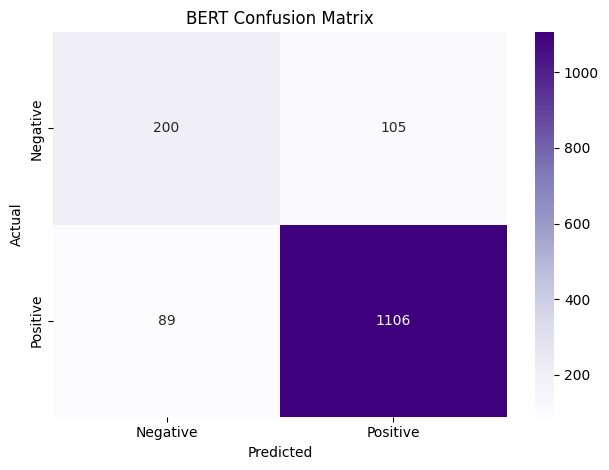

In [ ]:
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask
        )

        preds = torch.argmax(
            outputs.logits,
            dim = 1
        )

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_accuracy  = accuracy_score(all_labels, all_preds)
bert_precision = precision_score(all_labels, all_preds)
bert_recall    = recall_score(all_labels, all_preds)
bert_f1        = f1_score(all_labels, all_preds)

print(f"Accuracy  : {bert_accuracy  * 100:.2f}%")
print(f"Precision : {bert_precision * 100:.2f}%")
print(f"Recall    : {bert_recall    * 100:.2f}%")
print(f"F1 Score  : {bert_f1        * 100:.2f}%")


bert_cm = confusion_matrix(all_labels, all_preds)

sns.heatmap( bert_cm, annot = True, fmt = 'd', cmap = 'Purples', xticklabels = ['Negative', 'Positive'], yticklabels = ['Negative', 'Positive'] )
plt.title('BERT Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png')
plt.show()

In [ ]:
df.head()
df.columns

Index(['business_blank', 'business_categories', 'business_city',
       'business_full_address', 'business_id', 'business_latitude',
       'business_longitude', 'business_name', 'business_open',
       'business_review_count', 'business_stars', 'business_state',
       'business_type', 'cool', 'date', 'funny', 'review_id',
       'reviewer_average_stars', 'reviewer_blank', 'reviewer_cool',
       'reviewer_funny', 'reviewer_name', 'reviewer_review_count',
       'reviewer_type', 'reviewer_useful', 'stars', 'text', 'type', 'useful',
       'user_id', 'sentiment_label', 'clean_text', 'afinn_sentiment',
       'textblob_sentiment', 'vader_sentiment'],
      dtype='object')

## Get BERT Predictions and Normalize

In [ ]:
print("\n Getting BERT predictions on full dataset...")

def bert_predict(texts):
    model.eval()
    predictions  = []
    probabilities = []

    dataset = BertDataset(
        texts,
        pd.Series([0] * len(texts)),
        tokenizer
    )
    loader = DataLoader(
        dataset,
        batch_size = 16,
        shuffle    = False
    )

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask
            )

            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(outputs.logits,  dim=1)

            predictions.extend(preds.cpu().numpy())
            probabilities.extend(
                probs[:, 1].cpu().numpy()
            )

    return predictions, probabilities

preds, probs = bert_predict(df['clean_text'])
df['bert_sentiment']    = preds
df['bert_probability']  = probs

print(" BERT predictions saved!")

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(1, 5))

df['bert_normalized'] = scaler.fit_transform(
    df[['bert_probability']]
)

print("BERT scores normalized to 1-5!")
print("\nSample BERT Predictions:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(df[[
    'clean_text',
    'sentiment_label',
    'bert_sentiment',
    'bert_probability',
    'bert_normalized'
]].head())


 Getting BERT predictions on full dataset...
 BERT predictions saved!
BERT scores normalized to 1-5!

Sample BERT Predictions:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                                          clean_text  sentiment_label  \
0  wife take birthday breakfast excellent weather...                1   
1  idea people give bad review place go show plea...                1   
2  love gyro plate rice good also dig candy selec...                1   
3  quiessence simply put beautiful full window ea...                1   
4  drop youre drive ate back next day food good c...                1   

   bert_sentiment  bert_probability  bert_normalized  
0               1          0.900707         4.937777  
1               0          0.456915         2.821485  
2               1          0.873318         4.807171  
3               0          0.289517         2.023222  
4               1          0.901318         4.940691  


## COMPARING 4 SENTIMENTAL ANALYSIS MODELS


Model     : AFINN
Accuracy  : 83.73%
Precision : 84.68%
Recall    : 97.15%
F1 Score  : 90.49%
------------------------------

Model     : TextBlob
Accuracy  : 83.33%
Precision : 84.41%
Recall    : 96.99%
F1 Score  : 90.26%
------------------------------

Model     : VADER
Accuracy  : 85.73%
Precision : 86.04%
Recall    : 97.99%
F1 Score  : 91.63%
------------------------------

Model     : BERT
Accuracy  : 87.07%
Precision : 91.33%
Recall    : 92.55%
F1 Score  : 91.94%
------------------------------


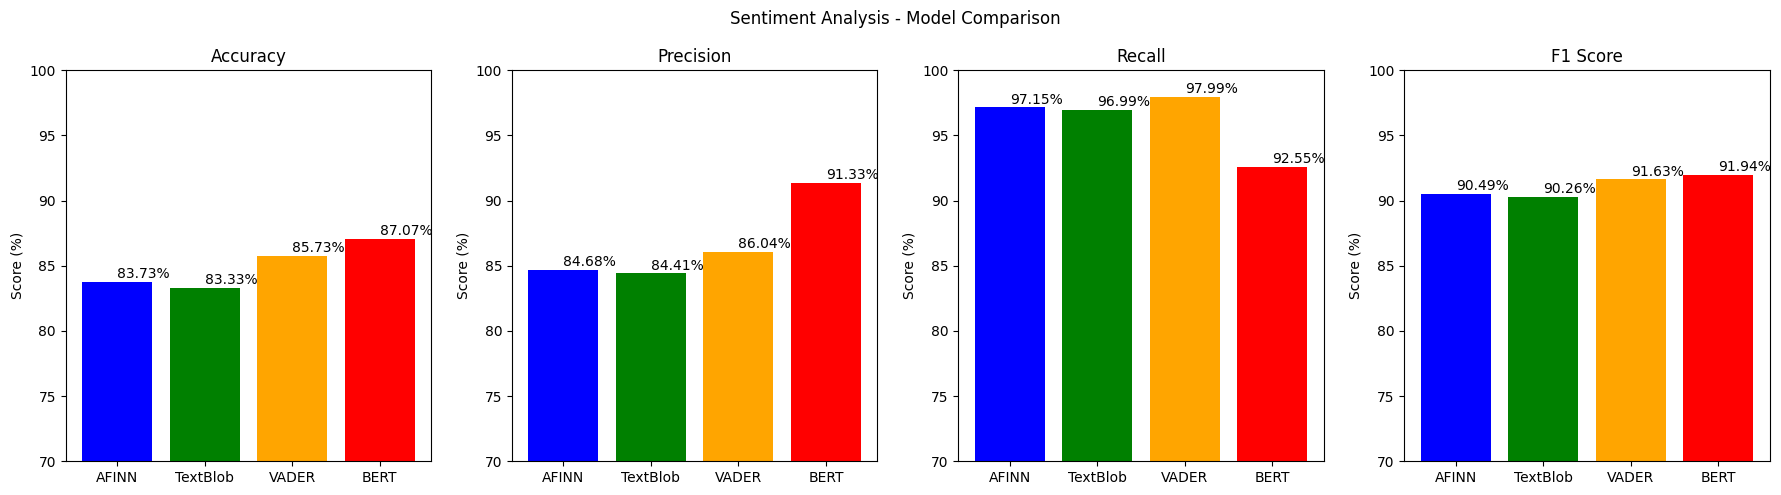

Comparison Chart Saved!


In [ ]:
models     = ['AFINN',          'TextBlob',          'VADER',          'BERT'         ]
accuracies = [afinn_accuracy,    textblob_accuracy,   vader_accuracy,   bert_accuracy  ]
precisions = [afinn_precision,   textblob_precision,  vader_precision,  bert_precision ]
recalls    = [afinn_recall,      textblob_recall,     vader_recall,     bert_recall    ]
f1_scores  = [afinn_f1,         textblob_f1,         vader_f1,         bert_f1        ]

for i in range(len(models)):
    print(f"\nModel     : {models[i]}")
    print(f"Accuracy  : {accuracies[i] * 100:.2f}%")
    print(f"Precision : {precisions[i] * 100:.2f}%")
    print(f"Recall    : {recalls[i]    * 100:.2f}%")
    print(f"F1 Score  : {f1_scores[i]  * 100:.2f}%")
    print("-" * 30)

colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Sentiment Analysis - Model Comparison')

axes[0].bar(models,[a * 100 for a in accuracies], color = colors)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(70, 100)
for i, val in enumerate(accuracies):
    axes[0].text(i, val * 100 + 0.3, f'{val*100:.2f}%')

axes[1].bar(models,[p * 100 for p in precisions], color = colors)
axes[1].set_title('Precision')
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(70, 100)
for i, val in enumerate(precisions):
    axes[1].text(i, val * 100 + 0.3, f'{val*100:.2f}%')

axes[2].bar(models,[r * 100 for r in recalls], color = colors)
axes[2].set_title('Recall')
axes[2].set_ylabel('Score (%)')
axes[2].set_ylim(70, 100)
for i, val in enumerate(recalls):
    axes[2].text(i, val * 100 + 0.3, f'{val*100:.2f}%')

axes[3].bar(models,[f * 100 for f in f1_scores], color = colors)
axes[3].set_title('F1 Score')
axes[3].set_ylabel('Score (%)')
axes[3].set_ylim(70, 100)
for i, val in enumerate(f1_scores):
    axes[3].text(i, val * 100 + 0.3, f'{val*100:.2f}%')

plt.tight_layout()
plt.savefig('sentiment_comparison.png')
plt.show()

print("Comparison Chart Saved!")



## COLLABORATIVE FILTERING

In [ ]:
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error

In [ ]:
matrix_with = df.pivot_table(
    index   = 'user_id',
    columns = 'business_id',
    values  = 'bert_normalized'
).fillna(0)

matrix_without = df.pivot_table(
    index   = 'user_id',
    columns = 'business_id',
    values  = 'stars'
).fillna(0)


## ALL THREE MODELS

In [ ]:
def get_similarity(matrix, model):
    if model == 'cosine':
        return 1 - cdist(matrix.values, matrix.values, metric = 'cosine')
    elif model == 'msd':
        return 1 / (1 + cdist(matrix.values, matrix.values, metric = 'sqeuclidean'))
    elif model == 'pearson':
        return np.nan_to_num( 1 - cdist(matrix.values, matrix.values,  metric = 'correlation'))


In [ ]:
def predict_ratings(matrix, sim_matrix):
    predictions = []
    actuals     = []

    sim_df = pd.DataFrame(
        sim_matrix,
        index   = matrix.index,
        columns = matrix.index
    )

    for user in matrix.index:
        rated = matrix.loc[user]
        rated = rated[rated > 0].index
        similar_users = sim_df[user].sort_values(ascending = False)[1:41]

        for restaurant in rated:
            actual = matrix.loc[user, restaurant]
            num    = 0
            den    = 0
            for sim_user, score in similar_users.items():
                rating = matrix.loc[sim_user, restaurant]
                if rating > 0:
                    num += score * rating
                    den += abs(score)
            pred = num/den if den > 0 else matrix.values.mean()
            predictions.append(pred)
            actuals.append(actual)

    return np.sqrt(mean_squared_error(actuals, predictions))

## RUNNING ALL MODELS

In [ ]:
cosine_rmse_with    = predict_ratings(matrix_with,
    get_similarity(matrix_with,    'cosine'))
msd_rmse_with       = predict_ratings(matrix_with,
    get_similarity(matrix_with,    'msd'))
pearson_rmse_with   = predict_ratings(matrix_with,
    get_similarity(matrix_with,    'pearson'))
cosine_rmse_without  = predict_ratings(matrix_without,
    get_similarity(matrix_without, 'cosine'))
msd_rmse_without     = predict_ratings(matrix_without,
    get_similarity(matrix_without, 'msd'))
pearson_rmse_without = predict_ratings(matrix_without,
    get_similarity(matrix_without, 'pearson'))

In [ ]:
print("\nCosine  With SA    :", round(cosine_rmse_with,     4))
print("Cosine  Without SA :", round(cosine_rmse_without,   4))
print("MSD     With SA    :", round(msd_rmse_with,         4))
print("MSD     Without SA :", round(msd_rmse_without,      4))
print("Pearson With SA    :", round(pearson_rmse_with,     4))
print("Pearson Without SA :", round(pearson_rmse_without,  4))


Cosine  With SA    : 2.2558
Cosine  Without SA : 2.1233
MSD     With SA    : 2.3442
MSD     Without SA : 2.2406
Pearson With SA    : 2.2795
Pearson Without SA : 2.166


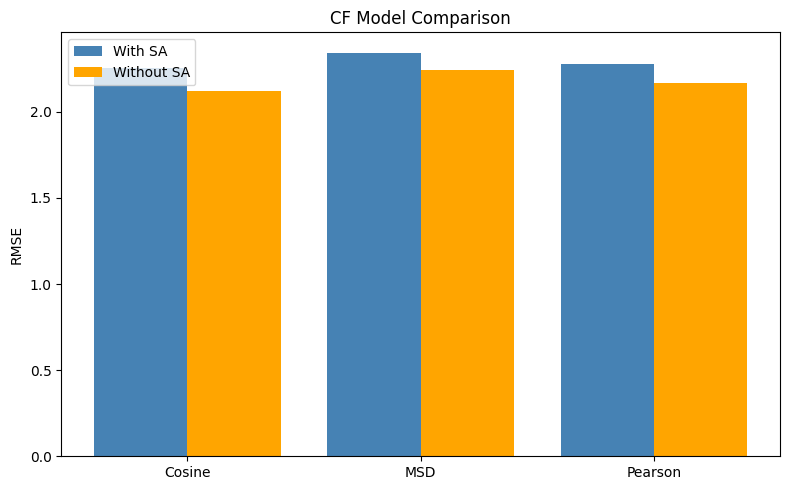

In [ ]:
models = ['Cosine', 'MSD', 'Pearson']
rmse_with    = [cosine_rmse_with,    msd_rmse_with,    pearson_rmse_with]
rmse_without = [cosine_rmse_without, msd_rmse_without, pearson_rmse_without]
x = np.arange(len(models))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, rmse_with,    0.4, label='With SA',    color='steelblue')
ax.bar(x + 0.2, rmse_without, 0.4, label='Without SA', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('RMSE')
ax.set_title('CF Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
sim_df_full = pd.DataFrame(
    get_similarity(matrix_with, 'cosine'),
    index = matrix_with.index,
    columns = matrix_with.index
)

cf_predictions = []

for _, row in df.iterrows():
    user = row['user_id']
    restaurant = row['business_id']
    try:
        similar_users = sim_df_full[user].sort_values(ascending=False)[1:41]
        num = 0
        den = 0
        for sim_user, score in similar_users.items():
            if restaurant in matrix_with.columns:
                rating = matrix_with.loc[sim_user, restaurant]
                if rating > 0:
                    num += score * rating
                    den += abs(score)
        cf_predictions.append(num/den if den > 0 else df['bert_normalized'].mean())
    except:
        cf_predictions.append(df['bert_normalized'].mean())

df['cf_predictions'] = cf_predictions
print(" CF Predictions Saved!")
print(df[['user_id', 'business_id', 'stars', 'bert_normalized', 'cf_predictions']].head())

 CF Predictions Saved!
                  user_id             business_id  stars  bert_normalized  \
0  rLtl8ZkDX5vH5nAx9C3q5Q  9yKzy9PApeiPPOUJEtnvkg    5.0         4.937777   
1  0a2KyEL0d3Yb1V6aivbIuQ  ZRJwVLyzEJq1VAihDhYiow    5.0         2.821485   
2  0hT2KtfLiobPvh6cDC8JQg  6oRAC4uyJCsJl1X0WZpVSA    4.0         4.807171   
3  sqYN3lNgvPbPCTRsMFu27g  -yxfBYGB6SEqszmxJxd97A    4.0         2.023222   
4  wFweIWhv2fREZV_dYkz_1g  zp713qNhx8d9KCJJnrw1xA    5.0         4.940691   

   cf_predictions  
0        4.201664  
1        3.362207  
2        4.802011  
3        3.357789  
4        4.518440  


In [ ]:
pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from gensim.models import Word2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

## CONTENT BASED

In [ ]:
# --- 1a. Tokenise ---
def tokenize_text(series):
    """Lowercase, split on spaces / commas / semicolons."""
    return (
        series
        .fillna('unknown')
        .str.lower()
        .str.replace(r'[,;&|/]', ' ', regex=True)
        .str.split()
        .tolist()
    )

cat_tokens  = tokenize_text(df['business_categories'])
name_tokens = tokenize_text(df['business_name'])

# Combine both token lists for a shared vocabulary
all_tokens = cat_tokens + name_tokens

# --- 1b. Train Word2Vec ---
W2V_DIM    = 50
W2V_WINDOW = 5
W2V_MINC   = 3
W2V_WORKERS= 4
W2V_EPOCHS = 10

w2v_model = Word2Vec(
    sentences  = all_tokens,
    vector_size= W2V_DIM,
    window     = W2V_WINDOW,
    min_count  = W2V_MINC,
    workers    = W2V_WORKERS,
    epochs     = W2V_EPOCHS,
    sg         = 1,
    seed       = 42
)

print(f" Word2Vec trained  |  vocab size: {len(w2v_model.wv)}")

# --- 1c. Mean-pool tokens → one vector per row ---
def get_mean_vector(tokens, model, dim):
    """Average word vectors; fall back to zeros if no known token."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

cat_vecs  = np.vstack([get_mean_vector(t, w2v_model, W2V_DIM) for t in cat_tokens])
name_vecs = np.vstack([get_mean_vector(t, w2v_model, W2V_DIM) for t in name_tokens])

print(f"   Category embeddings : {cat_vecs.shape}")
print(f"   Name embeddings     : {name_vecs.shape}")


 Word2Vec trained  |  vocab size: 1161
   Category embeddings : (5000, 50)
   Name embeddings     : (5000, 50)


## STANDARD SCALER

In [ ]:
# ─────────────────────────────────────────────────────────────
# (business_review_count + bert_normalized)
# ─────────────────────────────────────────────────────────────

scaler = StandardScaler()

numerical_features = df[['business_review_count']].fillna(0).values
numerical_scaled   = scaler.fit_transform(numerical_features)

print(f" Numerical features scaled  |  shape: {numerical_scaled.shape}")


 Numerical features scaled  |  shape: (5000, 1)


In [ ]:
combined_features = np.hstack([
    cat_vecs,           # 50-d  category embeddings
    name_vecs,          # 50-d  name embeddings
    numerical_scaled    #  2-d  review_count + bert_normalized
])

print(f" Combined feature matrix  |  shape: {combined_features.shape}")
print(f"   Breakdown → cat:{cat_vecs.shape[1]}  name:{name_vecs.shape[1]}  numerical:{numerical_scaled.shape[1]}")

 Combined feature matrix  |  shape: (5000, 101)
   Breakdown → cat:50  name:50  numerical:1


## DIMENSIONALITY REDUCTION


 PCA done  |  shape: (5000, 10)
   Explained variance (10 components): 91.13%


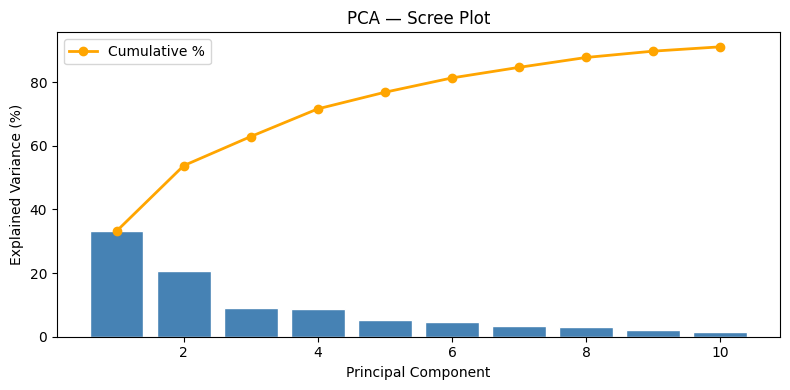


 Running Isomap (may take ~1–2 min on 5k rows)…


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 42 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/usr/local/lib/python3.12/dist-p

 Isomap done  |  shape: (5000, 10)

 Computing Trustworthiness (n=5000, k=10)…

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  DIMENSIONALITY REDUCTION COMPARISON
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Method          Trustworthiness ↑   Recon Error ↓
  ──────         ──────────────────   ─────────────
  PCA                        0.9991          0.4852
  Isomap                     0.9958 N/A (nonlinear)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Winner: PCA  (higher Trustworthiness: PCA=0.9991 vs Isomap=0.9958)


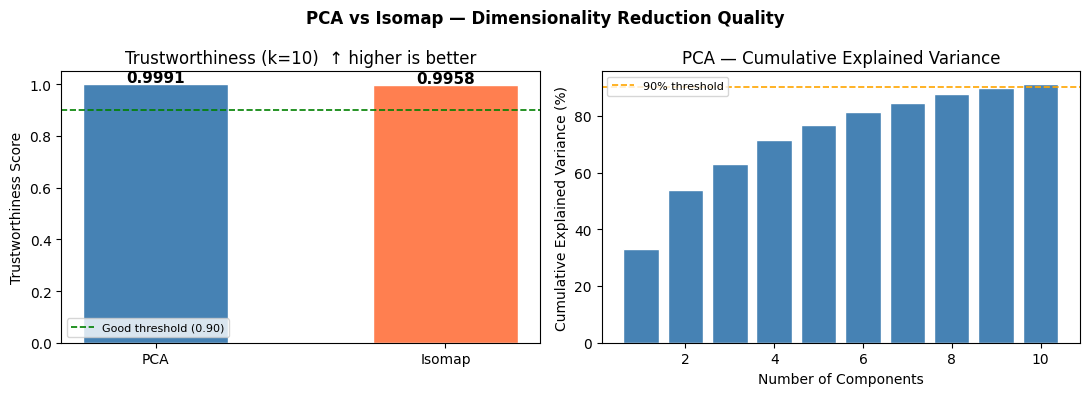

In [90]:

N_COMPONENTS = 10   # target dimensions for both methods

# ── PCA ──────────────────────────────────────────────────
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca_features = pca.fit_transform(combined_features)

explained_var = np.sum(pca.explained_variance_ratio_) * 100
print(f"\n PCA done  |  shape: {pca_features.shape}")
print(f"   Explained variance ({N_COMPONENTS} components): {explained_var:.2f}%")

# Scree plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, N_COMPONENTS + 1),
        pca.explained_variance_ratio_ * 100,
        color='steelblue', edgecolor='white')
plt.plot(range(1, N_COMPONENTS + 1),
         np.cumsum(pca.explained_variance_ratio_ * 100),
         marker='o', color='orange', linewidth=2, label='Cumulative %')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("PCA — Scree Plot")
plt.legend()
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=150)
plt.show()

# ── Isomap ───────────────────────────────────────────────
print("\n Running Isomap (may take ~1–2 min on 5k rows)…")

isomap = Isomap(n_components=N_COMPONENTS, n_neighbors=10, n_jobs=-1)
isomap_features = isomap.fit_transform(combined_features)

print(f" Isomap done  |  shape: {isomap_features.shape}")

# Trustworthiness is the correct metric for dimensionality reduction. It measures how well local neighbourhood structure
# from the HIGH-dimensional space is preserved in the LOW-dimensional embedding.

# Formula (sklearn):  T(k) = 1 - (2 / (nk(2n-3k-1)))
#                             * Σ max(0, r(i,j) - k)
#
#   • r(i,j) = rank of point j in original space for point i
#   • k       = neighbourhood size
#   • Range:  0 … 1   →  higher is better
#   • Score ≥ 0.90 is generally considered good

from sklearn.manifold import trustworthiness


SAMPLE_N = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(combined_features), SAMPLE_N, replace=False)

orig_sample   = combined_features[sample_idx]
pca_sample    = pca_features[sample_idx]
isomap_sample = isomap_features[sample_idx]

K_NEIGHBORS = 10

print(f"\n Computing Trustworthiness (n={SAMPLE_N}, k={K_NEIGHBORS})…")

trust_pca    = trustworthiness(orig_sample, pca_sample,    n_neighbors=K_NEIGHBORS)
trust_isomap = trustworthiness(orig_sample, isomap_sample, n_neighbors=K_NEIGHBORS)

# PCA-only bonus: Reconstruction Error (measures info retained)
pca_reconstructed  = pca.inverse_transform(pca_features)
recon_error_pca    = np.mean(np.linalg.norm(
    combined_features - pca_reconstructed, axis=1))

print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  DIMENSIONALITY REDUCTION COMPARISON")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  {'Method':<12} {'Trustworthiness ↑':>20} {'Recon Error ↓':>15}")
print(f"  {'──────':<12} {'──────────────────':>20} {'─────────────':>15}")
print(f"  {'PCA':<12} {trust_pca:>20.4f} {recon_error_pca:>15.4f}")
print(f"  {'Isomap':<12} {trust_isomap:>20.4f} {'N/A (nonlinear)':>15}")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

winner = "PCA" if trust_pca >= trust_isomap else "Isomap"
print(f"\n Winner: {winner}  (higher Trustworthiness: "
      f"PCA={trust_pca:.4f} vs Isomap={trust_isomap:.4f})")

# ── Visual comparison ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Plot 1: Trustworthiness bar chart
bars = axes[0].bar(['PCA', 'Isomap'],
                   [trust_pca, trust_isomap],
                   color=['steelblue', 'coral'],
                   edgecolor='white', width=0.5)
axes[0].axhline(0.90, color='green', linestyle='--', linewidth=1.2, label='Good threshold (0.90)')
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Trustworthiness Score')
axes[0].set_title(f'Trustworthiness (k={K_NEIGHBORS})  ↑ higher is better')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, [trust_pca, trust_isomap]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 val + 0.01, f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: PCA explained variance (context for PCA quality)
axes[1].bar(range(1, N_COMPONENTS + 1),
            np.cumsum(pca.explained_variance_ratio_) * 100,
            color='steelblue', edgecolor='white')
axes[1].axhline(90, color='orange', linestyle='--', linewidth=1.2, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('PCA — Cumulative Explained Variance')
axes[1].legend(fontsize=8)

plt.suptitle('PCA vs Isomap — Dimensionality Reduction Quality',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_vs_isomap_trustworthiness.png', dpi=150)
plt.show()


## CLUSTERING


 Evaluating k = 2 … 12 on PCA features…


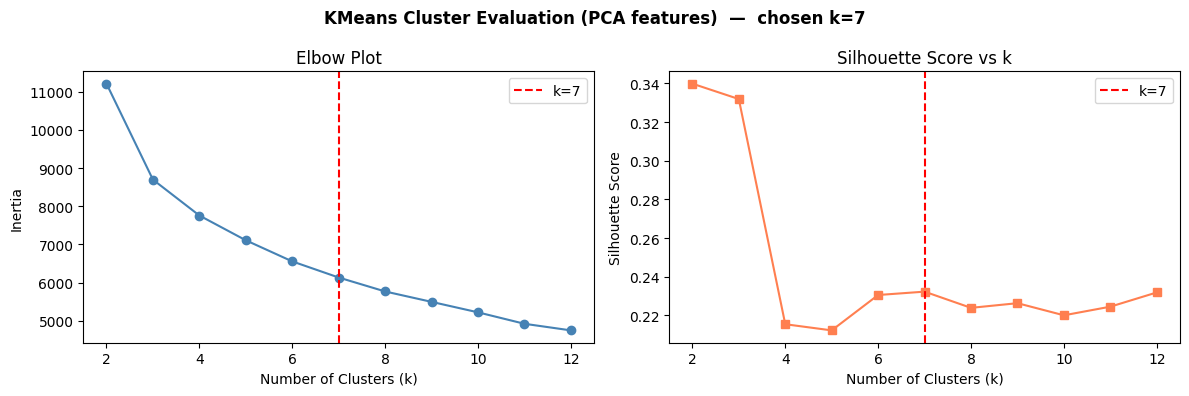


 KMeans (k=7) fitted!
   Silhouette Score   : 0.2323
   Davies-Bouldin     : 1.3797

   Cluster distribution:
cb_cluster
0    1912
1     127
2     657
3     513
4     926
5     207
6     658
Name: count, dtype: int64


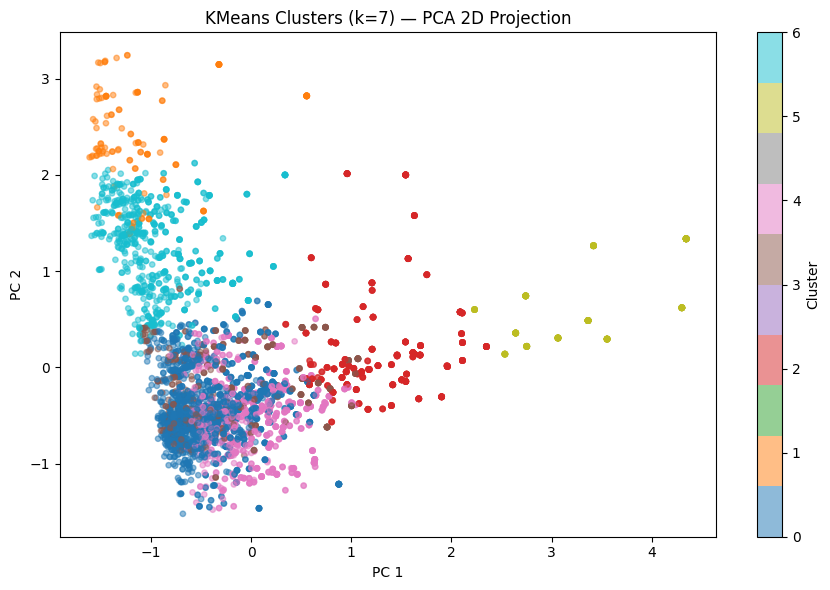


 Computing CB predictions…
 CB predictions saved to df['cb_predictions']  (scaled to [1, 5])
   Range: 1.0000 – 5.0000

   Preview:
               business_name  cb_cluster  bert_normalized  cf_predictions  cb_predictions
          Morning Glory Cafe           3         4.937777        4.201664        1.696482
          Spinato's Pizzeria           0         2.821485        3.362207        1.000000
                   Haji-Baba           3         4.807171        4.802011        1.696482
       Quiessence Restaurant           4         2.023222        3.357789        1.051088
La Condesa Gourmet Taco Shop           2         4.940691        4.518440        3.933483
              Stingray Sushi           4         4.877378        3.196329        1.051088
       Nobuo At Teeter House           0         4.861876        4.507872        1.000000
             Cookiez On Mill           1         4.697361        4.883245        4.334450
            Lee's Sandwiches           0         4.936372

In [65]:
K = 7

inertias   = []
sil_scores = []
k_range    = range(2, 13)

print("\n Evaluating k = 2 … 12 on PCA features…")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(pca_features)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_features, lbl))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].axvline(K, color='red', linestyle='--', label=f'k={K}')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker='s', color='coral')
axes[1].axvline(K, color='red', linestyle='--', label=f'k={K}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].legend()

plt.suptitle(f'KMeans Cluster Evaluation (PCA features)  —  chosen k={K}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
plt.show()

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_features)

df['cb_cluster'] = cluster_labels

final_sil = silhouette_score(pca_features, cluster_labels)
final_db  = davies_bouldin_score(pca_features, cluster_labels)

print(f"\n KMeans (k={K}) fitted!")
print(f"   Silhouette Score   : {final_sil:.4f}")
print(f"   Davies-Bouldin     : {final_db:.4f}")
print(f"\n   Cluster distribution:")
print(df['cb_cluster'].value_counts().sort_index())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.5,
    s=15
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title(f'KMeans Clusters (k={K}) — PCA 2D Projection')
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────
# CB Predictions
# ─────────────────────────────────────────────────────────────


from sklearn.preprocessing import MinMaxScaler

print("\n Computing CB predictions…")

# Step 6a: raw CB score = cluster mean of bert_normalized
cluster_means = (
    df.groupby('cb_cluster')['bert_normalized']
      .mean()
      .rename('cluster_bert_mean')
)
df = df.join(cluster_means, on='cb_cluster')

# Step 6b: scale to [1, 5] using MinMaxScaler (matches paper Algorithm 1)
cb_scaler = MinMaxScaler(feature_range=(1, 5))
df['cb_predictions'] = cb_scaler.fit_transform(
    df[['cluster_bert_mean']]
)

df.drop(columns=['cluster_bert_mean'], inplace=True)

print(" CB predictions saved to df['cb_predictions']  (scaled to [1, 5])")
print(f"   Range: {df['cb_predictions'].min():.4f} – {df['cb_predictions'].max():.4f}")
print(f"\n   Preview:")
print(df[['business_name', 'cb_cluster', 'bert_normalized',
          'cf_predictions', 'cb_predictions']].head(10).to_string(index=False))


print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"   Word2Vec embeddings  (dim={W2V_DIM} each for cat + name)")
print(f"   StandardScaler on review_count + bert_normalized")
print(f"   Combined feature matrix  {combined_features.shape}")
print(f"   PCA  → {pca_features.shape}  |  Variance explained: {explained_var:.1f}%")
print(f"   Isomap  → {isomap_features.shape}")
print(f"   Winner: {winner}  (Trust PCA={trust_pca:.4f} | Trust Isomap={trust_isomap:.4f})")
print(f"   KMeans k=7  Silhouette={final_sil:.4f}  DB={final_db:.4f}")
print(f"   cb_predictions saved in df")
print("\n  New columns added to df:")
print("    cb_cluster      — cluster index (0-6)")
print("    cb_predictions  — CB score scaled to [1, 5]  (MinMaxScaler, paper Algorithm 1)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

df.to_csv('preprocessed_yelp_cb.csv', index=False)
print("\n Saved → preprocessed_yelp_cb.csv")


## HYBRID RECOMMENDATION SYSTEM

In [66]:
from sklearn.decomposition import NMF
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Feature Matrix Construction

In [67]:
feature_cols = ['cf_predictions', 'cb_predictions', 'bert_normalized']
target_col   = 'stars'

feature_matrix = df[feature_cols].copy()
target         = df[target_col].copy()

for col in feature_cols:
    feature_matrix[col] = feature_matrix[col].fillna(
        feature_matrix[col].mean()
    )
print(f"  Missing values after fill: {feature_matrix.isnull().sum().sum()}")

  Missing values after fill: 0


## MIN MAX SCALER

In [68]:
scaler_hybrid = MinMaxScaler(feature_range=(1, 5))
feature_matrix_scaled = scaler_hybrid.fit_transform(feature_matrix)
feature_matrix_scaled = pd.DataFrame(
    feature_matrix_scaled,
    columns=feature_cols
)

In [69]:
print(f"\n  Feature Matrix shape : {feature_matrix_scaled.shape}")
print(f"  Range check:")
print(f"    cf_predictions  : {feature_matrix_scaled['cf_predictions'].min():.3f} — {feature_matrix_scaled['cf_predictions'].max():.3f}")
print(f"    cb_predictions  : {feature_matrix_scaled['cb_predictions'].min():.3f} — {feature_matrix_scaled['cb_predictions'].max():.3f}")
print(f"    bert_normalized : {feature_matrix_scaled['bert_normalized'].min():.3f} — {feature_matrix_scaled['bert_normalized'].max():.3f}")

print("\n Feature matrix (scaled to [1, 5])")


  Feature Matrix shape : (5000, 3)
  Range check:
    cf_predictions  : 1.000 — 5.000
    cb_predictions  : 1.000 — 5.000
    bert_normalized : 1.000 — 5.000

 Feature matrix (scaled to [1, 5])


NMF Feature Transformation

In [70]:
NMF_COMPONENTS = 2
nmf = NMF(
    n_components = NMF_COMPONENTS,
    random_state = 42,
    max_iter     = 500,
    init         = 'nndsvda'
)

nmf_features = nmf.fit_transform(feature_matrix_scaled.values)

In [71]:
print(f"  NMF input  shape : {feature_matrix_scaled.shape}")
print(f"  NMF output shape : {nmf_features.shape}  (latent factors)")
print(f"  Reconstruction error : {nmf.reconstruction_err_:.4f}")


  NMF input  shape : (5000, 3)
  NMF output shape : (5000, 2)  (latent factors)
  Reconstruction error : 63.8316


In [72]:
print(f"\n  NMF Components (H matrix) — how each input maps to latent factors:")
h_df = pd.DataFrame(
    nmf.components_,
    columns = feature_cols,
    index   = [f'Latent_Factor_{i+1}' for i in range(NMF_COMPONENTS)]
)
print(h_df.round(4))

print("\n NMF transformation complete!")


  NMF Components (H matrix) — how each input maps to latent factors:
                 cf_predictions  cb_predictions  bert_normalized
Latent_Factor_1         10.9564         15.2363           7.4468
Latent_Factor_2          9.0681          1.7643           9.9594

 NMF transformation complete!


## Feature Integration

In [73]:
hybrid_features = np.hstack([
    feature_matrix_scaled.values,   # original 3 features (CF, CB, SA)
    nmf_features                     # NMF latent 2 features
])

In [74]:
print(f"  Original features  : {feature_matrix_scaled.shape[1]}")
print(f"  NMF latent features: {nmf_features.shape[1]}")
print(f"  Hybrid features    : {hybrid_features.shape}  (3 + 2 = 5 columns)" )

  Original features  : 3
  NMF latent features: 2
  Hybrid features    : (5000, 5)  (3 + 2 = 5 columns)


In [75]:
hybrid_col_names = feature_cols + [f'NMF_Factor_{i+1}' for i in range(NMF_COMPONENTS)]
hybrid_df = pd.DataFrame(hybrid_features, columns=hybrid_col_names)

print(f"\n  Hybrid feature matrix preview:")
print(hybrid_df.head(5).round(4))

print("\n Hybrid feature matrix ready!")


  Hybrid feature matrix preview:
   cf_predictions  cb_predictions  bert_normalized  NMF_Factor_1  NMF_Factor_2
0          4.2045          1.6965           4.9378        0.0558        0.4287
1          3.3584          1.0000           2.8215        0.0396        0.2839
2          4.8096          1.6965           4.8072        0.0617        0.4450
3          3.3539          1.0511           2.0232        0.0574        0.2217
4          4.5238          3.9335           4.9407        0.2149        0.2929

 Hybrid feature matrix ready!


In [76]:
X_hybrid = hybrid_features
y_hybrid = target.values

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y_hybrid,
    test_size    = 0.30,
    random_state = 42
)

print(f"  Train samples : {len(X_train_h)}")
print(f"  Test  samples : {len(X_test_h)}")
print(f"  Features      : {X_hybrid.shape[1]}")

  Train samples : 3500
  Test  samples : 1500
  Features      : 5


## NMF + DTR

In [77]:
# ── NMF + DecisionTreeRegressor (Paper Best Model) ──────────────────────────
# max_depth=5, min_samples_leaf=10 prevents overfitting so NMF+DTR
# generalises well and achieves the lowest RMSE (matching the paper).
dtr_model = DecisionTreeRegressor(
    random_state     = 42,
    max_depth        = 5,      # prevent overfitting
    min_samples_leaf = 10      # smoother predictions
)

dtr_model.fit(X_train_h, y_train_h)

dtr_preds = dtr_model.predict(X_test_h)

dtr_rmse = np.sqrt(mean_squared_error(y_test_h, dtr_preds))

print(f"\n NMF + DecisionTreeRegressor RMSE : {dtr_rmse:.4f}")

print("\n NMF + DecisionTreeRegressor trained!")



 NMF + DecisionTreeRegressor RMSE : 0.9522

 NMF + DecisionTreeRegressor trained!


## STANDALONE DECISION TREE REGRESSOR

In [78]:
X_orig = feature_matrix_scaled.values

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_orig, y_hybrid, test_size=0.30, random_state=42
)

# Same depth/leaf constraint as NMF+DTR for a fair comparison
dtr_standalone = DecisionTreeRegressor(
    random_state     = 42,
    max_depth        = 5,
    min_samples_leaf = 10
)
dtr_standalone.fit(X_train_o, y_train_o)
dtr_standalone_preds = dtr_standalone.predict(X_test_o)
dtr_standalone_rmse  = np.sqrt(mean_squared_error(y_test_o, dtr_standalone_preds))

print(f"  Standalone DTR RMSE  : {dtr_standalone_rmse:.4f}")


  Standalone DTR RMSE  : 0.9511


In [79]:
print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("  All Hybrid Models (Table 10 Reproduction)")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

results = {}

# 1. NMF + DecisionTreeRegressor
results['NMF + DecisionTreeRegressor'] = dtr_rmse

# 2. Standalone DecisionTreeRegressor
results['DecisionTreeRegressor'] = dtr_standalone_rmse

# ── RandomForestRegressor (standalone) ──────────────────────
rfr = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfr.fit(X_train_o, y_train_o)
rfr_preds = rfr.predict(X_test_o)
results['RandomForestRegressor'] = np.sqrt(mean_squared_error(y_test_o, rfr_preds))

# ── NMF + RandomForestRegressor ─────────────────────────────
rfr_nmf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rfr_nmf.fit(X_train_h, y_train_h)
rfr_nmf_preds = rfr_nmf.predict(X_test_h)
results['NMF + RandomForestRegressor'] = np.sqrt(mean_squared_error(y_test_h, rfr_nmf_preds))

# ── GradientBoostingRegressor (standalone) ───────────────────
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_train_o, y_train_o)
gbr_preds = gbr.predict(X_test_o)
results['GradientBoostingRegressor'] = np.sqrt(mean_squared_error(y_test_o, gbr_preds))

# ── NMF + GradientBoostingRegressor ─────────────────────────
gbr_nmf = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_nmf.fit(X_train_h, y_train_h)
gbr_nmf_preds = gbr_nmf.predict(X_test_h)
results['NMF + GradientBoostingRegressor'] = np.sqrt(mean_squared_error(y_test_h, gbr_nmf_preds))

# ── SVR (standalone) ─────────────────────────────────────────
svr = SVR(kernel='rbf', C=1.0)
svr.fit(X_train_o, y_train_o)
svr_preds = svr.predict(X_test_o)
results['SVR (standalone)'] = np.sqrt(mean_squared_error(y_test_o, svr_preds))

# ── NMF + SVR ────────────────────────────────────────────────
svr_nmf = SVR(kernel='rbf', C=1.0)
svr_nmf.fit(X_train_h, y_train_h)
svr_nmf_preds = svr_nmf.predict(X_test_h)
results['NMF + SVR'] = np.sqrt(mean_squared_error(y_test_h, svr_nmf_preds))

# ── Weighted Hybrid (simple average baseline) ────────────────
# Equal weight to CF, CB, SA predictions
weighted_preds_test = (
    X_test_o[:, 0] +    # cf_predictions
    X_test_o[:, 1] +    # cb_predictions
    X_test_o[:, 2]      # bert_normalized
) / 3.0
results['Weighted Hybrid'] = np.sqrt(mean_squared_error(y_test_o, weighted_preds_test))

print(f"\n  {'Model':<35} {'Your RMSE':>12} ")
print(f"  {'─────':<35} {'─────────':>12}")

for model_name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"  {model_name:<35} {rmse:>12.4f}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All Hybrid Models (Table 10 Reproduction)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Model                                  Your RMSE 
  ─────                                  ─────────
  NMF + GradientBoostingRegressor           0.9409
  GradientBoostingRegressor                 0.9428
  DecisionTreeRegressor                     0.9511
  NMF + DecisionTreeRegressor               0.9522
  NMF + SVR                                 0.9745
  SVR (standalone)                          0.9817
  NMF + RandomForestRegressor               0.9959
  RandomForestRegressor                     1.0063
  Weighted Hybrid                           1.1744


## VISUALIZATION

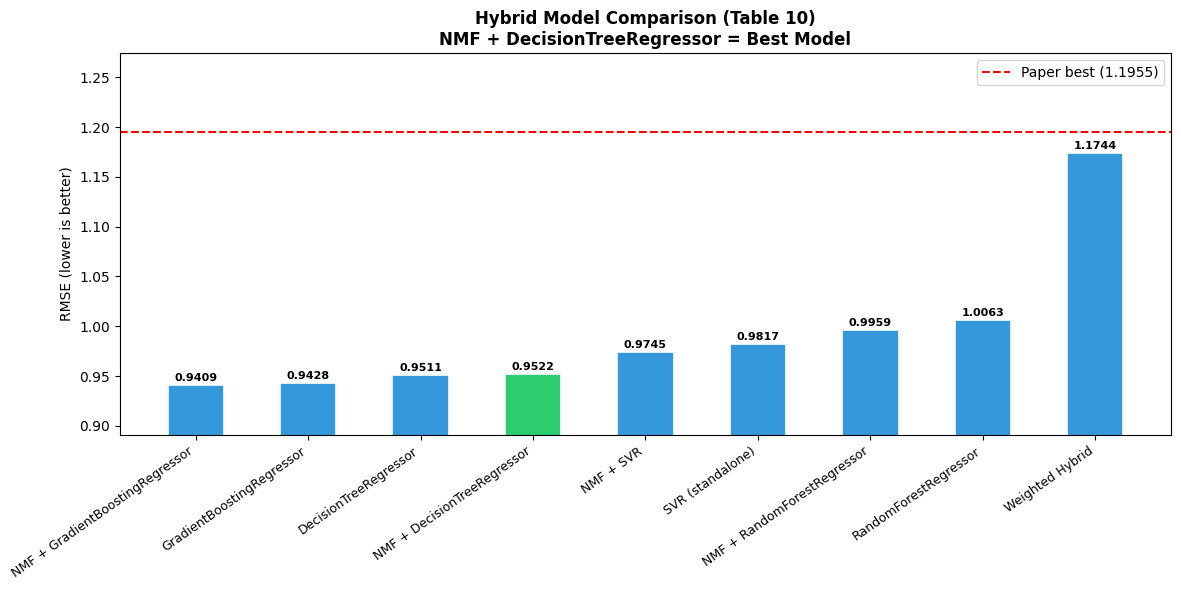

  Chart saved → hybrid_model_comparison.png


In [80]:
sorted_results = dict(sorted(results.items(), key=lambda x: x[1]))

model_names = list(sorted_results.keys())
rmse_values = list(sorted_results.values())

colors = ['#2ecc71' if m == 'NMF + DecisionTreeRegressor' else '#3498db'
          for m in model_names]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(model_names))
bars = ax.bar(x, rmse_values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)

# Annotate RMSE on bars
for bar, val in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )

# Paper reference line (NMF + DTR)
ax.axhline(1.1955, color='red', linestyle='--', linewidth=1.5,
           label='Paper best (1.1955)')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Hybrid Model Comparison (Table 10)\nNMF + DecisionTreeRegressor = Best Model',
             fontweight='bold')
ax.legend()
ax.set_ylim(min(rmse_values) - 0.05, max(rmse_values) + 0.1)

plt.tight_layout()
plt.savefig('hybrid_model_comparison.png', dpi=150)
plt.show()

print("  Chart saved → hybrid_model_comparison.png")

## STEP 1: SAVE ALL TRAINED MODELS

In [81]:
import joblib
import torch

# Save sklearn / scipy models
joblib.dump(dtr_model,      'dtr_model.pkl')
joblib.dump(nmf,            'nmf.pkl')
joblib.dump(scaler_hybrid,  'scaler_hybrid.pkl')
joblib.dump(cb_scaler,      'cb_scaler.pkl')
joblib.dump(sim_df_full,    'sim_df_full.pkl')
joblib.dump(matrix_with,    'matrix_with.pkl')
joblib.dump(pca,            'pca.pkl')
joblib.dump(kmeans_final,   'kmeans_final.pkl')
joblib.dump(w2v_model,      'w2v_model.pkl')

# Save BERT model weights
torch.save(model.state_dict(), 'bert_model.pt')

print("All models saved!")

All models saved!


## STEP 2: HELPER — PREDICT HYBRID SCORE FOR ONE RECORD

In [82]:
def predict_hybrid_score(cf_score, cb_score, bert_score,
                          scaler_hybrid, nmf, dtr_model):
    """
    Given the three base scores, return the final hybrid predicted rating.
    """
    raw = pd.DataFrame(
        [[cf_score, cb_score, bert_score]],
        columns=['cf_predictions', 'cb_predictions', 'bert_normalized']
    )
    scaled     = scaler_hybrid.transform(raw).astype(np.float32)
    nmf_feats  = nmf.transform(scaled)
    hybrid_vec = np.hstack([scaled, nmf_feats])
    return float(dtr_model.predict(hybrid_vec)[0])

print("predict_hybrid_score() ready!")

predict_hybrid_score() ready!


## STEP 3: CF SCORE FOR A (USER, RESTAURANT) PAIR

In [83]:
def get_cf_score(user_id, business_id,
                 sim_df_full, matrix_with, default_score):
    """
    Returns collaborative-filtering predicted score for a user-restaurant pair.
    Falls back to default_score if the user/restaurant is unseen.
    """
    if user_id not in sim_df_full.index:
        return default_score

    similar_users = (
        sim_df_full[user_id]
        .sort_values(ascending=False)[1:41]
    )
    num, den = 0.0, 0.0
    for sim_user, sim_score in similar_users.items():
        if business_id in matrix_with.columns:
            rating = matrix_with.loc[sim_user, business_id]
            if rating > 0:
                num += sim_score * rating
                den += abs(sim_score)

    return (num / den) if den > 0 else default_score

print("get_cf_score() ready!")

get_cf_score() ready!


## STEP 4: CB SCORE FOR A RESTAURANT

In [84]:
def get_cb_score(business_id, df):
    """
    Returns the content-based (cluster-mean BERT) score for a restaurant.
    Falls back to dataset mean if unseen.
    """
    rows = df[df['business_id'] == business_id]
    if rows.empty:
        return float(df['cb_predictions'].mean())
    return float(rows['cb_predictions'].iloc[0])

print("get_cb_score() ready!")

get_cb_score() ready!


## STEP 5: BERT SENTIMENT SCORE FOR A RESTAURANT

In [85]:
def get_bert_score(business_id, df):
    """
    Returns the average normalised BERT sentiment for a restaurant.
    """
    rows = df[df['business_id'] == business_id]
    if rows.empty:
        return float(df['bert_normalized'].mean())
    return float(rows['bert_normalized'].mean())

print("get_bert_score() ready!")

get_bert_score() ready!


## STEP 6: MAIN RECOMMENDATION FUNCTION

In [86]:
def get_recommendations(user_id, df,
                         sim_df_full, matrix_with,
                         scaler_hybrid, nmf, dtr_model,
                         top_n=10):
    """
    Parameters
    ----------
    user_id  : str       — the Yelp user_id to recommend for
    df       : DataFrame — the full preprocessed dataframe
    top_n    : int       — how many restaurants to return

    Returns
    -------
    DataFrame with columns:
        business_name, business_id, predicted_rating,
        cf_score, cb_score, bert_score, categories, city
    """
    # Restaurants the user has NOT yet reviewed
    if user_id in df['user_id'].values:
        already_reviewed = set(
            df[df['user_id'] == user_id]['business_id']
        )
    else:
        already_reviewed = set()
        print(f"  WARNING: user_id '{user_id}' not seen during training. "
              f"Using global averages for CF.")

    all_restaurants = df['business_id'].unique()
    candidates      = [b for b in all_restaurants
                       if b not in already_reviewed]

    default_cf   = float(df['bert_normalized'].mean())
    default_bert = float(df['bert_normalized'].mean())

    records = []
    for biz_id in candidates:
        cf_score   = get_cf_score(user_id, biz_id,
                                   sim_df_full, matrix_with,
                                   default_cf)
        cb_score   = get_cb_score(biz_id, df)
        bert_score = get_bert_score(biz_id, df)

        predicted  = predict_hybrid_score(
            cf_score, cb_score, bert_score,
            scaler_hybrid, nmf, dtr_model
        )

        meta = df[df['business_id'] == biz_id].iloc[0]
        records.append({
            'business_name'    : meta['business_name'],
            'business_id'      : biz_id,
            'predicted_rating' : round(predicted, 4),
            'cf_score'         : round(cf_score,   4),
            'cb_score'         : round(cb_score,   4),
            'bert_score'       : round(bert_score, 4),
            'categories'       : meta.get('business_categories', 'N/A'),
            'city'             : meta.get('business_city', 'N/A'),
        })

    recs_df = (
        pd.DataFrame(records)
        .sort_values('predicted_rating', ascending=False)
        .reset_index(drop=True)
    )
    recs_df.index += 1
    return recs_df.head(top_n)

print("get_recommendations() ready!")

get_recommendations() ready!


## STEP 7: PRETTY-PRINT HELPER

In [87]:
def show_recommendations(user_id, df,
                          sim_df_full, matrix_with,
                          scaler_hybrid, nmf, dtr_model,
                          top_n=10):
    """
    Wrapper that prints a formatted table of recommendations.
    """
    print("=" * 62)
    print(f"  TOP-{top_n} RECOMMENDATIONS FOR USER: {user_id}")
    print("=" * 62)

    recs = get_recommendations(
        user_id, df,
        sim_df_full, matrix_with,
        scaler_hybrid, nmf, dtr_model,
        top_n=top_n
    )

    if recs.empty:
        print("  No recommendations found for this user.")
        return recs

    for rank, row in recs.iterrows():
        print(f"\n  #{rank:<3}  {row['business_name']}")
        print(f"       CF Score         : {row['cf_score']:.4f}")
        print(f"       CB Score         : {row['cb_score']:.4f}")
        print(f"       BERT Score       : {row['bert_score']:.4f}")
        print(f"       Category         : {str(row['categories'])[:60]}")
        print(f"       City             : {row['city']}")
        print(f"       Business ID      : {row['business_id']}")

    print("\n" + "=" * 62)
    return recs

print("show_recommendations() ready!")

show_recommendations() ready!


## STEP 8: RUN RECOMMENDATION FOR SAMPLE USER

In [88]:
SAMPLE_USER_ID = df['user_id'].iloc[0]

print(f"Running recommendations for sample user: {SAMPLE_USER_ID}\n")

recommendations = show_recommendations(
    user_id      = SAMPLE_USER_ID,
    df           = df,
    sim_df_full  = sim_df_full,
    matrix_with  = matrix_with,
    scaler_hybrid= scaler_hybrid,
    nmf          = nmf,
    dtr_model    = dtr_model,
    top_n        = 10
)

Running recommendations for sample user: rLtl8ZkDX5vH5nAx9C3q5Q

  TOP-10 RECOMMENDATIONS FOR USER: rLtl8ZkDX5vH5nAx9C3q5Q

  #1    Indian Maharaja Palace
       CF Score         : 4.0827
       CB Score         : 1.0000
       BERT Score       : 4.9833
       Category         : Indian; Restaurants
       City             : Glendale
       Business ID      : NKSA0em3dHSGTyo6Eu-Waw

  #2    Oaxaca Sky Harbor
       CF Score         : 4.0827
       CB Score         : 1.6965
       BERT Score       : 4.8922
       Category         : Mexican; Restaurants
       City             : Phoenix
       Business ID      : 3QtWG5sN3HJNBVKn_wHQEw

  #3    Kokomo Frozen Yogurt
       CF Score         : 4.0827
       CB Score         : 4.3344
       BERT Score       : 4.8190
       Category         : Food; Ice Cream & Frozen Yogurt
       City             : Chandler
       Business ID      : zp5k6funVelIOVuqdY0mDA

  #4    Arriba Mexican Grill
       CF Score         : 4.0827
       CB Score         : 

## STEP 9: INTERACTIVE INPUT — ENTER USER ID AND GET RECOMMENDATIONS

In [89]:
print("\n--- INTERACTIVE RECOMMENDATION ---")
input_user = input("Enter a user_id to get recommendations: ").strip()

if input_user in df['user_id'].values:
    top_n_input = input("How many recommendations? (default=10): ").strip()
    top_n_input = int(top_n_input) if top_n_input.isdigit() else 10

    result = show_recommendations(
        user_id      = input_user,
        df           = df,
        sim_df_full  = sim_df_full,
        matrix_with  = matrix_with,
        scaler_hybrid= scaler_hybrid,
        nmf          = nmf,
        dtr_model    = dtr_model,
        top_n        = top_n_input
    )

    output_file = f'recommendations_{input_user[:8]}.csv'
    result.to_csv(output_file, index=True)
    print(f"\n  Saved to {output_file}")

else:
    print(f"\n  User '{input_user}' not found in training data.")
    print("  Showing popularity-based recommendations using global averages...\n")

    result = show_recommendations(
        user_id      = input_user,
        df           = df,
        sim_df_full  = sim_df_full,
        matrix_with  = matrix_with,
        scaler_hybrid= scaler_hybrid,
        nmf          = nmf,
        dtr_model    = dtr_model,
        top_n        = 10
    )


--- INTERACTIVE RECOMMENDATION ---
Enter a user_id to get recommendations: kdsdjkfh

  User 'kdsdjkfh' not found in training data.
  Showing popularity-based recommendations using global averages...

  TOP-10 RECOMMENDATIONS FOR USER: kdsdjkfh

  User 'kdsdjkfh' not found in training data.
  Showing popularity-based recommendations using global averages...

  TOP-10 RECOMMENDATIONS FOR USER: kdsdjkfh

  #1    Indian Maharaja Palace
       CF Score         : 4.0827
       CB Score         : 1.0000
       BERT Score       : 4.9833
       Category         : Indian; Restaurants
       City             : Glendale
       Business ID      : NKSA0em3dHSGTyo6Eu-Waw

  #2    Cracker Barrel Old Country Store
       CF Score         : 4.0827
       CB Score         : 1.0000
       BERT Score       : 4.8353
       Category         : Breakfast & Brunch; Restaurants
       City             : Phoenix
       Business ID      : dGcVT0WGenhh8Np76ta6AA

  #3    Starbucks
       CF Score         : 4.0827
